In [1]:
import os

from dotenv import load_dotenv

load_dotenv()



True

In [2]:
%load_ext autoreload
%autoreload 2

# 深度研究智能体

## 概述

<img src="./resources/agent_header.png" width="800" style="display:block; margin-left:0;">

现在，我们可以将所学的一切整合在一起：

* 我们将使用 **TODOs** 来跟踪任务。
* 我们将使用 **文件** 来存储原始工具调用结果。
* 我们将 **将研究任务委派给子智能体** 以实现上下文隔离。

## 搜索工具

我们将构建一个搜索工具，将原始内容卸载到文件中，并仅向智能体返回摘要。这是长时运行智能体轨迹的常见模式，[正如我们在 Manus 中所见](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus)！

### 核心组件

1. **搜索执行 (`run_tavily_search`)**：使用 Tavily API 执行实际的网页搜索，可配置结果数量和主题过滤参数。

2. **内容摘要 (`summarize_webpage_content`)**：使用轻量级模型（deepseek-chat）生成网页内容的结构化摘要，生成描述性文件名和关键学习摘要。

3. **结果处理 (`process_search_results`)**：通过 HTTP 获取完整网页内容，使用 `markdownify` 将 HTML 转换为 markdown，并为每个结果生成摘要。

4. **上下文卸载 (`tavily_search` 工具)**：主要工具，功能包括：
   - 执行搜索并处理结果
   - 将完整内容保存到智能体状态的文件中（上下文卸载）
   - 仅向智能体返回最小摘要（防止上下文垃圾）
   - 使用 LangGraph `Command` 更新文件和消息

5. **战略思考 (`think_tool`)**：为智能体提供结构化反思机制，用于分析发现、评估差距并规划研究工作流程中的下一步。

该架构通过将详细的搜索结果存储在文件中，同时保持智能体的工作上下文最小化和聚焦，解决了令牌效率问题。


<div style="background-color: #fff3b0; padding: 10px; border-radius: 4px;">
<b>注意：</b>  
<code>create_react_agent</code> 已从 LangGraph 库移至 LangChain 库，并在 1.0 代码发布中（拍摄完成后）重命名为 <code>create_agent</code>。导入和代码有细微更改以适应此变化。视频可能显示之前的配置。
</div>

In [3]:
%%writefile ../../src/deep_agents_from_scratch/research_tools.py
"""Research Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""
import os
from datetime import datetime
import uuid, base64

import httpx
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import InjectedToolArg, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command
from markdownify import markdownify
from pydantic import BaseModel, Field
from tavily import TavilyClient
from typing_extensions import Annotated, Literal

from deep_agents_from_scratch.prompts import SUMMARIZE_WEB_SEARCH
from deep_agents_from_scratch.state import DeepAgentState

# Summarization model 
summarization_model = init_chat_model(
    model="deepseek-chat",  # Qwen3 14B via Ollama (previously: openai:gpt-4o-mini)
    temperature=0.0,
)
tavily_client = TavilyClient()

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    filename: str = Field(description="Name of the file to store.")
    summary: str = Field(description="Key learnings from the webpage.")

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def run_tavily_search(
    search_query: str, 
    max_results: int = 1, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> dict:
    """Perform search using Tavily API for a single query.

    Args:
        search_query: Search query to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        Search results dictionary
    """
    result = tavily_client.search(
        search_query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic
    )

    return result

def summarize_webpage_content(webpage_content: str) -> Summary:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Summary object with filename and summary
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary_and_filename = structured_model.invoke([
            HumanMessage(content=SUMMARIZE_WEB_SEARCH.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        return summary_and_filename
        
    except Exception:
        # Return a basic summary object on failure
        return Summary(
            filename="search_result.md",
            summary=webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content
        )


def process_search_results(results: dict) -> list[dict]:
    """Process search results by summarizing content where available.

    Args:
        results: Tavily search results dictionary

    Returns:
        List of processed results with summaries
    """
    processed_results = []

    # Create a client for HTTP requests with timeout
    HTTPX_CLIENT = httpx.Client(timeout=60.0)  # Add 60 second timeout

    for result in results.get('results', []):

        # Get url 
        url = result['url']

        # Read url with timeout and error handling
        try:
            response = HTTPX_CLIENT.get(url)
        
            if response.status_code == 200:
                # Convert HTML to markdown
                raw_content = markdownify(response.text)
                summary_obj = summarize_webpage_content(raw_content)
            else:
                # Use Tavily's generated summary
                raw_content = result.get('raw_content', '')
                summary_obj = Summary(
                    filename="URL_error.md",
                    summary=result.get('content', 'Error reading URL; try another search.')
                )
        except (httpx.TimeoutException, httpx.RequestError) as e:
            # Handle timeout or connection errors gracefully
            raw_content = result.get('raw_content', '')
            summary_obj = Summary(
                filename="connection_error.md",
                summary=result.get('content', f'Could not fetch URL (timeout/connection error). Try another search.')
            )

        # uniquify file names
        uid = base64.urlsafe_b64encode(uuid.uuid4().bytes).rstrip(b"=").decode("ascii")[:8]
        name, ext = os.path.splitext(summary_obj.filename)
        summary_obj.filename = f"{name}_{uid}{ext}"

        processed_results.append({
            'url': result['url'],
            'title': result['title'],
            'summary': summary_obj.summary,
            'filename': summary_obj.filename,
            'raw_content': raw_content,
        })

    return processed_results


@tool(parse_docstring=True)
def tavily_search(
    query: str,
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
    max_results: Annotated[int, InjectedToolArg] = 1,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> Command:
    """Search web and save detailed results to files while returning minimal context.

    Performs web search and saves full content to files for context offloading.
    Returns only essential information to help the agent decide on next steps.

    Args:
        query: Search query to execute
        state: Injected agent state for file storage
        tool_call_id: Injected tool call identifier
        max_results: Maximum number of results to return (default: 1)
        topic: Topic filter - 'general', 'news', or 'finance' (default: 'general')

    Returns:
        Command that saves full results to files and provides minimal summary
    """
    # Execute search
    search_results = run_tavily_search(
        query,
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    ) 

    # Process and summarize results
    processed_results = process_search_results(search_results)
    
    # Save each result to a file and prepare summary
    files = state.get("files", {})
    saved_files = []
    summaries = []
    
    for i, result in enumerate(processed_results):
        # Use the AI-generated filename from summarization
        filename = result['filename']
        
        # Create file content with full details
        file_content = f"""# Search Result: {result['title']}

**URL:** {result['url']}
**Query:** {query}
**Date:** {get_today_str()}

## Summary
{result['summary']}

## Raw Content
{result['raw_content'] if result['raw_content'] else 'No raw content available'}
"""
        
        files[filename] = file_content
        saved_files.append(filename)
        summaries.append(f"- {filename}: {result['summary']}...")
    
    # Create minimal summary for tool message - focus on what was collected
    summary_text = f"""🔍 Found {len(processed_results)} result(s) for '{query}':

{chr(10).join(summaries)}

Files: {', '.join(saved_files)}
💡 Use read_file() to access full details when needed."""

    return Command(
        update={
            "files": files,
            "messages": [
                ToolMessage(summary_text, tool_call_id=tool_call_id)
            ],
        }
    )

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.

    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.

    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    - How complex is the question: Have I reached the number of search limits?

    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?

    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps

    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

Overwriting ../../src/deep_agents_from_scratch/research_tools.py


## Deep Agent

Now, we can just apply all of our prior learnings: 

* We'll give the researcher a `think_tool` and our `search_tool` above.
* We'll give our parent agent file tools, a `think_tool`, and a `task` tool. 

In [4]:
from datetime import datetime

from IPython.display import Image, display
import os
from langchain.chat_models import init_chat_model
#from langgraph.prebuilt import create_react_agent
from langchain.agents import create_agent
from utils import show_prompt, stream_agent

from deep_agents_from_scratch.file_tools import ls, read_file, write_file
from deep_agents_from_scratch.prompts import (
    FILE_USAGE_INSTRUCTIONS,
    RESEARCHER_INSTRUCTIONS,
    SUBAGENT_USAGE_INSTRUCTIONS,
    TODO_USAGE_INSTRUCTIONS,
)
from deep_agents_from_scratch.research_tools import tavily_search, think_tool, get_today_str
from deep_agents_from_scratch.state import DeepAgentState
from deep_agents_from_scratch.task_tool import _create_task_tool
from deep_agents_from_scratch.todo_tools import write_todos, read_todos

# Create agent using create_react_agent directly
model = init_chat_model(
    model="deepseek-chat",  # Qwen3 14B via Ollama (previously: anthropic:claude-sonnet-4-20250514)
    # base_url="http://localhost:11434/v1",
    # openai_api_key="ollama",  # Ollama doesn't require a real API key, but ChatOpenAI expects one
    temperature=0.0,
)

# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Tools
sub_agent_tools = [tavily_search, think_tool]
built_in_tools = [ls, read_file, write_file, write_todos, read_todos, think_tool]

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "prompt": RESEARCHER_INSTRUCTIONS.format(date=get_today_str()),
    "tools": ["tavily_search", "think_tool"],
}

# Create task tool to delegate tasks to sub-agents
task_tool = _create_task_tool(
    sub_agent_tools, [research_sub_agent], model, DeepAgentState
)

delegation_tools = [task_tool]
all_tools = sub_agent_tools + built_in_tools + delegation_tools  # search available to main agent for trivial cases

# Build prompt
SUBAGENT_INSTRUCTIONS = SUBAGENT_USAGE_INSTRUCTIONS.format(
    max_concurrent_research_units=max_concurrent_research_units,
    max_researcher_iterations=max_researcher_iterations,
    date=datetime.now().strftime("%a %b %-d, %Y"),
)

In [5]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 1-2 search tool calls maximum                                                        │
│  - **Normal queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Very Complex queries**: Use up to 5 search tool calls maximum                                              │
│  - **Always stop**: After 5 search tool calls if you c

In [6]:
INSTRUCTIONS = (
    "# TODO MANAGEMENT\n"
    + TODO_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# FILE SYSTEM USAGE\n"
    + FILE_USAGE_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    + "# SUB-AGENT DELEGATION\n"
    + SUBAGENT_INSTRUCTIONS
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # TODO MANAGEMENT                                                                                              │
│  Based upon the user's request:                                                                                 │
│  1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.           │
│  2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan.  │
│  3. Reflect on what you've done and the TODO.                                                                   │
│  4. Mark you task as completed, and proceed to the next TODO.                                                   │
│  5. Continue this process until you have completed all TODOs.                                                   │
│                                                                                                                 │
│  IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY  │
│  user request.                                                                                                  │
│  IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have  │
│  to keep track of.                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # FILE SYSTEM USAGE                                                                                            │
│  You have access to a virtual file system to help you retain and save context.                                  │
│                                                                                                                 │
│  ## Workflow Process                                                                                            │
│  1. **Orient**: Use ls() to see existing files before starting work                                             │
│  2. **Save**: Use write_file() to store the user's request so that we can keep it for later                     │
│  3. **Research**: Proceed with research. The search tool will write files.                                      │
│  4. **Read**: Once you are satisfied with the collected sources, read the files and use them to answer the      │
│  user's question directly.                                                                                      │
│                                                                                                                 │
│                                                                                                                 │
│  ================================================================================                               │
│                                                                                                                 │
│  # SUB-AGENT DELEGATION                                                                                         │
│  You can delegate tasks to sub-agents.                                                                          │
│                                                                                                                 │
│  <Task>                                               

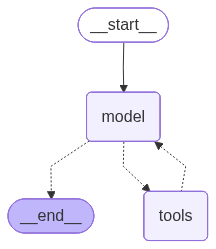

In [7]:
# Create agent
agent = create_agent(  #updated 1.0
    model, all_tools, system_prompt=INSTRUCTIONS, state_schema=DeepAgentState
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [8]:
from utils import format_messages

result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an overview of Model Context Protocol (MCP).",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an overview of Model Context Protocol (MCP).                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll start by creating a TODO list and researching the Model Context Protocol (MCP).                            │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research Model Context Protocol (MCP) - overview, purpose, and key concepts",                 │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Research MCP architecture, components, and how it works",                                     │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Compile findings into a comprehensive overview",                                              │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_00_oJncN32Sh6EPVFoIk51D5547                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Research Model Context Protocol (MCP) - overview, purpose, and key           │
│ concepts', 'status': 'in_progress'}, {'content': 'Research MCP architecture, components, and how it works',     │
│ 'status': 'pending'}, {'content': 'Compile findings into a comprehensive overview', 'status': 'pending'}]       │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP overview what is it"                                                     │
│ }                                                                                                               │
│    ID: call_00_CqNvrrHNMghrL45iAa0P7225                                                                         │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP architecture how it works"                                               │
│ }                                                                                                               │
│    ID: call_01_ZH4xk3Wibq4O8bFxbrxy9187                                                                         │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP use cases benefits"                                                      │
│ }                                                                                                               │
│    ID: call_02_mFu4p1HVVhvEeU9lWaZA0656                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 🔍 Found 1 result(s) for 'Model Context Protocol MCP overview what is it':                                      │
│                                                                                                                 │
│ - mcp_protocol_overview_tutorial_HG1yy2FQ.md: Tutorial/overview of the Model Context Protocol (MCP), an open    │
│ standard by Anthropic for standardizing AI application integrations with external tools and data. Key points:   │
│ (1) MCP transforms the M×N integration problem into an M+N problem using a client-server architecture with      │
│ Tools, Resources, and Prompts. (2) Built on JSON-RPC 2.0 with strong spec, SDKs, and growing ecosystem (OpenAI, │
│ Cursor, Windsurf support). Includes practical Python code examples for building MCP servers and clients....     │
│                                                                                                                 │
│ Files: mcp_protocol_overview_tutorial_HG1yy2FQ.md                                                               │
│ 💡 Use read_file() to access full details when needed.                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "file_path": "mcp_overview.md",                                                                               │
│   "content": "# Model Context Protocol (MCP) — Comprehensive Overview\n\n## What is MCP?\n\n**Model Context     │
│ Protocol (MCP)** is an open standard introduced by **Anthropic** in late 2024 that provides a standardized way  │
│ for AI applications (chatbots, IDE assistants, custom agents) to connect with external tools, data sources, and │
│ systems. It's designed to solve the integration challenges that arise when building LLM-powered                 │
│ applications.\n\nThink of it as **\"USB-C for AI integrations\"** — before USB, connecting peripherals required │
│ a mess of different ports and custom drivers. Similarly, integrating AI applications with external tools was an │
│ **M×N problem**: if you have M different AI applications and N different tools/systems, you'd need to build M×N │
│ different integrations. MCP transforms this into an **M+N problem** by providing a common, standardized         │
│ API.\n\n---\n\n## Core Architecture\n\nMCP follows a **client-server architecture** with three main             │
│ components:\n\n### 1. Hosts\nApplications the user interacts with — where the LLMs live. Examples:\n- **UI      │
│ Apps**: Claude Desktop, Microsoft Copilot Studio, LibreChat, Claude Code\n- **IDEs**: Cursor, Windsurf,         │
│ Continue, Zed, Cline\n- **Custom Agents**: LangGraph, OpenAI Agents SDK, Firebase Genkit\n\n### 2.              │
│ Clients\nLightweight protocol clients embedded within hosts. Each client maintains a **1:1 connection** with a  │
│ specific MCP server. They handle connection management, capability discovery, request forwarding, and response  │
│ handling.\n\n### 3. Servers\nIndependent processes that expose capabilities via the MCP standard. They act as   │
│ bridges between the MCP world and external systems (APIs, databases, local files, etc.). Servers expose three   │
│ types of capabilities:\n\n| Capability | Control | Description |\n|---|---|---|\n| **Tools** | Model-controlled │
│ | Functions that LLMs can call to perform actions (e.g., weather API, GitHub API) — similar to function calling │
│ |\n| **Resources** | Application-controlled | Data sources that LLMs can access — similar to GET endpoints in   │
│ REST APIs, no side effects |\n| **Prompts** | User-controlled | Pre-defined templates for using tools/resources │
│ optimally, selected before inference |\n\n---\n\n## How MCP Works — The Connection Lifecycle\n\n### 1.          │
│ Initialization (Handshake)\nWhen a Host application starts, it creates MCP Clients which exchange information   │
│ about capabilities and protocol versions with servers via a handshake:\n- Client sends an `initialize` request  │
│ with its protocol version and supported features\n- Server responds with its own version and advertised         │
│ capabilities\n- Client sends an `initialized` notification to acknowledge completion\n\n### 2.                  │
│ Discovery\nClients request what capabilities (Tools, Resources, Prompts) the server offers. The server responds │
│ with a list and descriptions.\n\n### 3. Context Provision\nThe Host makes resources and prompts available to    │
│ the user, or parses tools into an LLM-compatible format (e.g., JSON function calling).\n\n### 4. Invocation\nIf │
│ the LLM determines it needs to use a Tool (e.g., \"What 

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file mcp_overview.md                                                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research Model Context Protocol (MCP) - overview, purpose, and key concepts",                 │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Research MCP architecture, components, and how it works",                                     │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Compile findings into a comprehensive overview",                                              │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_00_e9MkJvEiVpa6VG6V0w0k9062                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Research Model Context Protocol (MCP) - overview, purpose, and key           │
│ concepts', 'status': 'completed'}, {'content': 'Research MCP architecture, components, and how it works',       │
│ 'status': 'completed'}, {'content': 'Compile findings into a comprehensive overview', 'status': 'completed'}]   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Here's a comprehensive overview of the **Model Context Protocol (MCP)**:                                        │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## What is MCP?                                                                                                 │
│                                                                                                                 │
│ **Model Context Protocol (MCP)** is an **open standard introduced by Anthropic** (late 2024) that standardizes  │
│ how AI applications connect with external tools, data sources, and systems. Think of it as **"USB-C for AI      │
│ integrations"** — it solves the **M×N integration problem** (where M AI apps need N different custom            │
│ integrations) by turning it into an **M+N problem** through a common API.                                       │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## Architecture (3 Core Components)                                                                             │
│                                                                                                                 │
│ | Component | Role | Examples |                                                                                 │
│ |---|---|---|                                                                                                   │
│ | **Host** | The application the user interacts with (where the LLM lives) | Claude Desktop, Cursor, VS Code |  │
│ | **Client** | Lightweight protocol client; 1:1 connection with a server | Embedded within the Host |           │
│ | **Server** | Exposes capabilities (Tools, Resources, Prompts) via MCP | GitHub server, Filesystem server,     │
│ Slack server |                                                                                                  │
│                                                                                                                 │
│ **Three capability types:**                                                                                     │
│ - **Tools** (Model-controlled) — Functions the LLM can call (e.g., `fetch_github_issues`)                       │
│ - **Resources** (Application-controlled) — Data sources the LLM can read (e.g., file contents)                  │
│ - **Prompts** (User-controlled) — Pre-defined templates for optimal tool/resource usage                         │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## How It Works (Lifecycle)                                                                                     │
│                                                                                                                 │
│ 1. **Initialization** — Client and server perform a handshake, negotiating protocol versions and capabilities   │
│ 2. **Discovery** — Client asks what tools/resources/prompts the server offers                                   │
│ 3. **Context Provision** — Host makes capabilities avai

Trace: 
https://smith.langchain.com/public/3a389ec6-8e6e-4f9e-9a82-0d0a9569e6f8/r
<!-- https://smith.langchain.com/public/1df7a10e-1465-499c-a3e0-86c1d5429324/r -->

## Using the Deep Agent Package

Now you understand the underlying patterns! 

You can [use the `deepagents` package](
https://github.com/hwchase17/deepagents) as a simple abstraction:

* It include the file system tools
* It includes the todo tool
* It includes the task tool

You only need to supply the sub-agent and any tools you want the sub-agent to use.

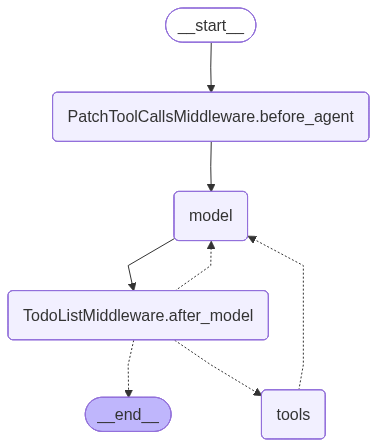

In [9]:
from deepagents import create_deep_agent
# updated since filming

# Create research sub-agent
research_sub_agent_2 = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=get_today_str()),
    "tools": [tavily_search, think_tool],
}


agent = create_deep_agent(  # updated 
    tools=sub_agent_tools,
    system_prompt=INSTRUCTIONS,
    subagents=[research_sub_agent_2],
    model=model,
)

# Show the agent
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [10]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Give me an very brief overview of Model Context Protocol (MCP).",
            }
        ],
    }
)

format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ Give me an very brief overview of Model Context Protocol (MCP).                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Let me research this quickly.                                                                                   │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Model Context Protocol MCP overview"                                                                │
│ }                                                                                                               │
│    ID: call_00_vGLnJ0KY8T1YzKrGmhPL1085                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 🔍 Found 1 result(s) for 'Model Context Protocol MCP overview':                                                 │
│                                                                                                                 │
│ - mcp_protocol_overview_tutorial_X2eVdZqW.md: Tutorial/overview of the Model Context Protocol (MCP), an open    │
│ standard by Anthropic for standardizing AI application integrations with external tools and systems. Key        │
│ points: (1) MCP transforms the M×N integration problem into an M+N problem using a client-server architecture   │
│ with Tools, Resources, and Prompts; (2) It gained significant momentum in early 2025 due to being AI-native,    │
│ having a strong spec, built on JSON-RPC/LSP foundations, and network effects with major tools like Cursor and   │
│ OpenAI adopting it....                                                                                          │
│                                                                                                                 │
│ Files: mcp_protocol_overview_tutorial_X2eVdZqW.md                                                               │
│ 💡 Use read_file() to access full details when needed.                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "/root/.openclaw/workspace/research/mcp_protocol_overview_tutorial_X2eVdZqW.md"                  │
│ }                                                                                                               │
│    ID: call_00_rgYqQLdsWSQsVoD1iy464384                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Error: File '/root/.openclaw/workspace/research/mcp_protocol_overview_tutorial_X2eVdZqW.md' not found           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "modelcontextprotocol.io introduction page \"MCP is an open protocol\" \"USB-C\" text content page   │
│ content page content page content page content page content page content page content page content page content │
│ page content page content page"                                                                                 │
│ }                                                                                                               │
│    ID: call_00_uep8NLXd9cKEUn46irY64931                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 🔍 Found 1 result(s) for 'modelcontextprotocol.io introduction page "MCP is an open protocol" "USB-C" text      │
│ content page content page content page content page content page content page content page content page content │
│ page content page content page content page':                                                                   │
│                                                                                                                 │
│ - URL_error_2L5rAVcc.md: At its core, MCP is an open protocol that standardizes how AI applications connect to  │
│ external data sources and tools. Think of it as USB-C for...                                                    │
│                                                                                                                 │
│ Files: URL_error_2L5rAVcc.md                                                                                    │
│ 💡 Use read_file() to access full details when needed.                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "/root/.openclaw/workspace/research/URL_error_2L5rAVcc.md"                                       │
│ }                                                                                                               │
│    ID: call_00_kML0Q3abr4RXuK6XK4PS9114                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Error: File '/root/.openclaw/workspace/research/URL_error_2L5rAVcc.md' not found                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I have enough information from the search results to give you a brief overview.                                 │
│                                                                                                                 │
│ **Model Context Protocol (MCP)** is an open protocol created by Anthropic that standardizes how AI applications │
│ connect to external data sources, tools, and services. It's often described as **"USB-C for AI"** — a single    │
│ universal interface instead of custom integrations for every tool.                                              │
│                                                                                                                 │
│ **Key points:**                                                                                                 │
│ - **Architecture**: Client-server model using JSON-RPC 2.0. An MCP host (e.g., Claude Desktop, an IDE) connects │
│ to MCP servers that provide context and capabilities.                                                           │
│ - **Server primitives**: **Resources** (data/files), **Tools** (executable actions), and **Prompts**            │
│ (templates).                                                                                                    │
│ - **Client primitives**: **Sampling** (LLM requests), **Roots** (workspace boundaries), and **Elicitation**.    │
│ - **Why it matters**: Transforms the M×N integration problem (every AI app × every tool) into M+N (one          │
│ protocol, many implementations). Supported by Claude, ChatGPT, VS Code, Cursor, and others.                     │
│ - **Security**: Emphasizes user consent, data privacy, and controlled tool execution.                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Trace: 
https://smith.langchain.com/public/1d626d81-a102-4588-a2fb-cab40a7271f1/r
<!-- https://smith.langchain.com/public/1ae2d7f6-f901-4ebd-b6c3-6657a55f88ae/r -->

## 流式运行智能体

实时观察智能体的思考过程、工具调用、子智能体委派响应，包含子图名称和节点信息。

In [11]:
from utils import stream_agent
import asyncio

await stream_agent(
    agent,
    {"messages": [{"role": "user", "content": "请给我一个关于MCP的概述。"}]},
)

Graph: root
Node: PatchToolCallsMiddleware.before_agent
Graph: root
Node: model


╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Let me research MCP (Model Context Protocol) and provide you with a comprehensive overview.                     │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Research MCP (Model Context Protocol) - what it is, key concepts, architecture",              │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Compile and present a comprehensive overview",                                                │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: call_00_f77a4AgTGlwnqp4UiyLk8609                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Graph: root
Node: TodoListMiddleware.after_model
Graph: root
Node: tools


╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Research MCP (Model Context Protocol) - what it is, key concepts,            │
│ architecture', 'status': 'in_progress'}, {'content': 'Compile and present a comprehensive overview', 'status':  │
│ 'pending'}]                                                                                                     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Graph: root
Node: model


...

Graph: root
Node: model


╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 以上就是 MCP 的完整概述。如果你对某个具体方面（比如如何搭建一个 MCP                                             │
│ 服务器、或者某个原语的详细用法）感兴趣，我可以进一步深入介绍。                                                  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Graph: root
Node: TodoListMiddleware.after_model


{'messages': [HumanMessage(content='请给我一个关于MCP的概述。', additional_kwargs={}, response_metadata={}, id='26e5180a-582e-4cfc-aac5-5a64ebdaca1a'),
  AIMessage(content='Let me research MCP (Model Context Protocol) and provide you with a comprehensive overview.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 112, 'prompt_tokens': 7154, 'total_tokens': 7266, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 7040}, 'prompt_cache_hit_tokens': 7040, 'prompt_cache_miss_tokens': 114}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'c506007c-2686-4912-889c-3c965eebdd30', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ebd21-8057-79e0-bb17-eff8463a3efa-0', tool_calls=[{'name': 'write_todos', 'args': {'todos': [{'content': 'Research MCP (Model Context Protocol) - what it is, key concepts, architectu

Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by ProtocolError('Connection aborted.', TimeoutError('The write operation timed out')))"))
Content-Length: 11135046
API Key: lsv2_********************************************aatrace=019ebd21-8032-7f81-982d-f861f81732e5,id=019ebd26-324f-7772-b385-cc08983524f7; trace=019ebd21-8032-7f81-982d-f861f81732e5,id=019ebd26-3245-7872-899e-2c1a807595b2; trace=019ebd21-8032-7f81-982d-f861f81732e5,id=019ebd26-3232-7640-830a-6185a6b0a502; trace=019ebd21-8032-7f81-982d-f861f81732e5,id=019ebd26-3231-7063-bea4-ba446fe62ee1; trace=019ebd21-8032-7f81-982d-f861f81732e5,id=019ebd26-322e-74e1-856b-e16ba3482ce7; trace=019ebd21-8032-7f81-982d-f861f81732e5,id=019ebd26-322c-75c1-